# Basic Roadmap

Three things of interest to me are:
1. Class to pull libraries from Enrichr for use downstream
2. Class to enable reweighting via optimal transport.
3. Class to generate a result dataframe, which contains meta-estimates for the z-score, LFCs and standard errors.

then, I want to be able to easily generate forest plots with the contribution and the meta-estimate at the bottom.

# Dataset

In [76]:
df = pd.read_csv("DE_Results.csv").set_index("symbol")

# 1. Pulling from Enrichr

In [77]:
import requests
from functools import reduce

class GeneOntologyLibraries:
    _base_url = "https://maayanlab.cloud/Enrichr/geneSetLibrary"

    def pull_library(self, library_name: str):
        params = {
            "mode": "text",
            "libraryName": library_name,
        }
        response = requests.get(self._base_url, params=params)
        response.raise_for_status()

        return {
            line.split("\t\t")[0]: line.split("\t\t")[1].rstrip("\n").split("\t")
            for line in response.text.strip().splitlines()
        }

    def pull_assignment_matrix(self, library_name: str):
        # Pull the library
        library = self.pull_library(library_name)

        # Unique Genes
        unique_genes = set(reduce(lambda x, y: x + y, library.values()))

        # Fill the assignment matrix
        return pd.DataFrame({k: {f: 1 for f in v} for k, v in library.items()}).fillna(0)

In [ ]:
go_terms = GeneOntologyLibraries().pull_assignment_matrix("GO_Molecular_Function_2025")

# Reweighting via IPF

In [681]:
# Worst name ever.
class ReweightingPreparer:

    @staticmethod
    def clean(go_terms, deseq_results):
        joint_index = go_terms.index.intersection(deseq_results.index)

        go_terms = go_terms.loc[joint_index]
        go_terms = go_terms.loc[:, go_terms.sum(axis=0).gt(0)]
        deseq_results = deseq_results.loc[joint_index]

        row_marginals = deseq_results["baseMean"].apply(np.log1p)
        column_marginals = go_terms.sum(axis=0).apply(np.log1p)

        return deseq_results, go_terms, row_marginals, column_marginals

In [682]:
deseq_results, go_terms, row_marginals, column_marginals = ReweightingPreparer.clean(go_terms, df)

In [683]:
import numpy as np
import pandas as pd
from tqdm import tqdm

class IterativeProportionalFitting:

    def get_balanced_matrix(
        self, 
        assignment_matrix: pd.DataFrame, 
        row_marginals: pd.Series, 
        column_marginals: pd.Series,
        max_iter = 1000,
        tolerance = 1e-3
    ):

        # Align matricies, we're going to strip off their indicies.
        # FIXME: I feel like this is bad form generally
        A = assignment_matrix.values
        u = row_marginals.values
        v = column_marginals.values

        delta = 1

        with tqdm(range(max_iter), desc="IPF Running") as pbar:
            for _ in pbar:
                # Rescale
                A_u1 = ((A * u[:, None]) / A.sum(axis=0))
                A_u2 = ((A_u1 * v) / A_u1.sum(axis=0))

                # Compute % change in Frobenius Norm
                delta = np.pow((A - A_u2), 2).sum() / np.pow(A, 2).sum()
                pbar.set_postfix({"% Change (Frob Norm)": delta})

                # Update matrix
                A = A_u2

                if delta < tolerance:
                    return pd.DataFrame(
                        A,
                        index=assignment_matrix.index,
                        columns=assignment_matrix.columns
                    )

        return pd.DataFrame(
            A,
            index=assignment_matrix.index,
            columns=assignment_matrix.columns
        )

In [684]:
balanced_matrix = IterativeProportionalFitting().get_balanced_matrix(
    go_terms, 
    row_marginals, 
    column_marginals,
)

IPF Running:   2%|▏         | 19/1000 [00:00<00:27, 35.87it/s, % Change (Frob Norm)=0.000951]


# Reweighting and Fitting

In [685]:
from scipy.stats import norm

class GeneOntologyDifferentialResults:

    def meta_estimates(deseq_results, balanced_matrix):
        # weight / se ^ 2
        weighted_precision = balanced_matrix.div(deseq_results["lfcSE"].pow(2), axis=0)

        # Balanced estimate of log2change, based on weight and precision, we prefer estimates which are precise (1/se^2),
        # includes both the precision of the coefficent estimate and the number of samples), and are expressed highly (weight). 
        # We incorporate all those changes, and then normalize by the total weighted precision.
        meta_beta = (deseq_results['log2FoldChange'].values @ weighted_precision) / weighted_precision.sum(axis=0)

        # Weighted precision estimates
        # sqrt(sum of weights^2 * SE^2)
        q = (balanced_matrix.pow(2) / balanced_matrix.pow(2).sum(axis=0))
        meta_se = (q.pow(2).T * deseq_results["lfcSE"].pow(2)) \
            .T \
            .sum(axis=0) \
            .apply(np.sqrt)

        # Compute two tailed p-values
        pvalues = (2 * norm.sf(np.abs(meta_beta/meta_se)))

        df = pd.DataFrame({
            "n_terms": balanced_matrix.gt(0).sum(axis=0),
            "metaLFC": meta_beta, 
            "metaSE": meta_se,
            "lower_ci": meta_beta - 1.96 * meta_se,
            "upper_ci": meta_beta + 1.96 * meta_se,
            "weight": balanced_matrix.sum(axis=0),
            "pval": pvalues,
            "padj": pvalues * meta_beta.shape[0],
            "log10p": -np.log10(pvalues),
            "log10padj": -np.log10(pvalues * meta_beta.shape[0]),
            "top1_contribution": balanced_matrix.div(balanced_matrix.sum(axis=0), axis=1).max(axis=0),
            "top5_contribution": (balanced_matrix.div(balanced_matrix.sum(axis=0), axis=1).apply(lambda col: col.nlargest(5).sum(), axis=0)),
            "N_eff": 1 / (balanced_matrix / balanced_matrix.sum(axis=0)).pow(2).sum(),
        })

        return df

gene_ontology_results = GeneOntologyDifferentialResults.meta_estimates(deseq_results, balanced_matrix)

,n_terms,metaLFC,metaSE,lower_ci,upper_ci,weight,pval,padj,log10p,log10padj,top1_contribution,top5_contribution,N_eff
GSE108654 Islets-vs-hESC-OE Hs Islets Up,100,1.012753,0.144843,0.728861,1.296644,4.615121,2.708233e-12,1.624940e-09,11.567314,8.789163,0.443751,0.841743,3.851791
GSE41203 6Wks NonObeseDiab Mm Chip Islets Dn,68,0.643461,0.122916,0.402546,0.884375,4.234107,1.650050e-07,9.900298e-05,6.782503,4.004352,0.416320,0.922891,3.482869
GSE156067 PCOS Day7 Hs SubcutaneousAdipose Up,121,1.226707,0.259270,0.718537,1.734877,4.804021,2.229970e-06,1.337982e-03,5.651701,2.873550,0.327094,0.917118,3.842382
GSE153222 FatDiet 4Wks Mm Islet Up,44,-1.413934,0.369790,-2.138723,-0.689145,3.806662,1.315117e-04,7.890704e-02,3.881035,1.102884,0.367565,0.851493,4.567607
GSE120429 D316ATrans ChowDiet Mm SubcutWAT Dn,40,0.446284,0.133233,0.185148,0.707420,3.713572,8.091107e-04,4.854664e-01,3.091992,0.313841,0.752319,0.940279,1.732954
GSE120290 Young-Old Mm Chip Muscle-Quads Up,81,-0.397141,0.126347,-0.644780,-0.149502,4.406719,1.670742e-03,1.002445e+00,2.777090,-0.001061,0.772091,0.938938,1.651778
GSE149468 Fasting-2Hrs Mm SubcutWAT Up,61,0.364092,0.116870,0.135026,0.593157,4.127134,1.837295e-03,1.102377e+00,2.735821,-0.042330,0.412800,0.813468,4.232472
GSE144274 Healthy-vs-(IPAH) Hs Muscle Dn,142,-1.072752,0.362868,-1.783973,-0.361531,4.962845,3.113377e-03,1.868026e+00,2.506768,-0.271383,0.600745,0.840086,2.638373
GSE154198 Passage113 Hs Chip Hepatocyte Up,96,0.726400,0.246068,0.244107,1.208694,4.574711,3.156941e-03,1.894164e+00,2.500734,-0.277418,0.228793,0.776708,7.037405
GSE73433 Ctrl-vs-Ctrl-shRNA Hs Islet Up,127,1.067824,0.363748,0.354878,1.780770,4.852030,3.328863e-03,1.997318e+00,2.477704,-0.300447,0.429140,0.897829,3.076866


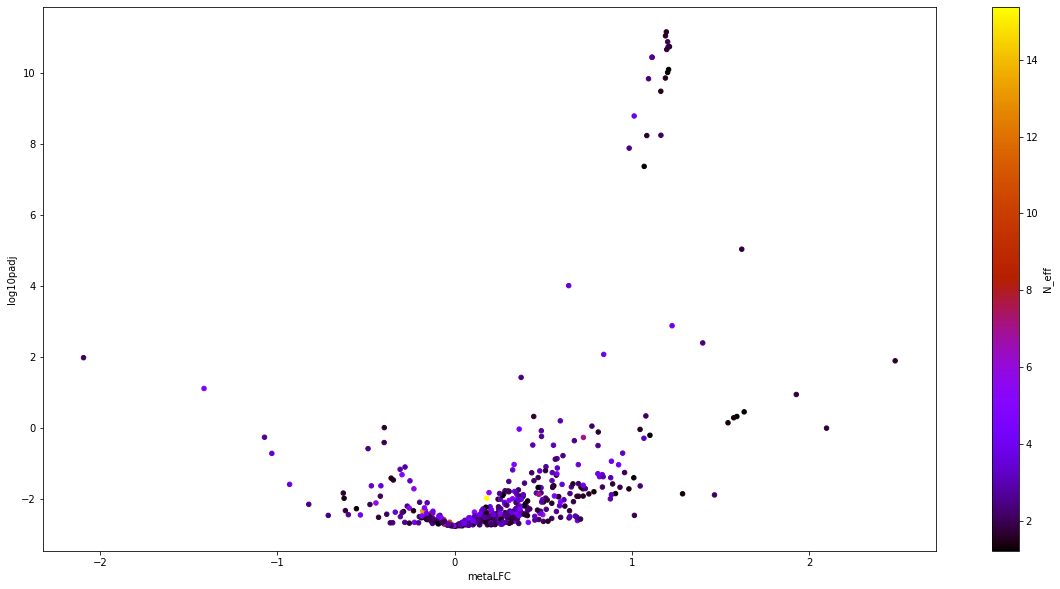

In [686]:
gene_ontology_results = GeneOntologyDifferentialResults.meta_estimates(deseq_results, balanced_matrix)
gene_ontology_results.query("top1_contribution < 0.9").plot.scatter(x="metaLFC", y="log10padj", c="N_eff", figsize=(20, 10), cmap="gnuplot")
gene_ontology_results.sort_values(by="padj").query("pval < 0.05 and n_terms > 1").query("top5_contribution < 0.95")

# Plotter

Given a go term, a balanced matrix, deseq results, and the global results, we would like to be able to plot a forest plot that displays:
- relative weight of a gene to the term
- estimates for that term
- global estimate

In [687]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


class ForestPlotter:

    def __init__(self, deseq_results, balanced_matrix, gene_ontology_results):
        self.deseq_results = deseq_results
        self.balanced_matrix = balanced_matrix
        self.gene_ontology_results = gene_ontology_results

    def plot_term(
        self,
        term: str,
        cutoff=0.99,
        figsize=None,
        ci_multiplier=1.96,
        point_size=45,
        contribution_label=True,
        title=None,
    ):
        contributing_genes = self.balanced_matrix.index[
            self.balanced_matrix[term].gt(0)
        ]

        subset_df = self.deseq_results.loc[contributing_genes].copy()
        subset_weights = self.balanced_matrix.loc[contributing_genes, term]

        contribution = subset_weights / subset_weights.sum()
        meta_estimation = self.gene_ontology_results.loc[term]

        forest_df = pd.DataFrame({
            "gene": subset_df.index,
            "L2FC": subset_df["log2FoldChange"],
            "SE": subset_df["lfcSE"],
            "lower_ci": subset_df["log2FoldChange"] - ci_multiplier * subset_df["lfcSE"],
            "upper_ci": subset_df["log2FoldChange"] + ci_multiplier * subset_df["lfcSE"],
            "pct_contribution": contribution,
        })

        forest_df = forest_df.replace([np.inf, -np.inf], np.nan).dropna(
            subset=["L2FC", "SE", "pct_contribution"]
        )

        if cutoff is not None:
            keep_genes = (
                forest_df
                .sort_values("pct_contribution", ascending=False)
                .assign(cum_contribution=lambda df: df["pct_contribution"].cumsum())
                .loc[lambda df: df["cum_contribution"].le(cutoff), "gene"]
            )

            if len(keep_genes) == 0:
                keep_genes = (
                    forest_df
                    .sort_values("pct_contribution", ascending=False)
                    .head(1)["gene"]
                )

            forest_df = forest_df.loc[forest_df["gene"].isin(keep_genes)]

        forest_df = forest_df.sort_values("pct_contribution", ascending=True)

        n_genes = len(forest_df)

        if figsize is None:
            figsize = (11, max(5, 0.32 * n_genes + 2.5))

        fig, ax = plt.subplots(
            nrows=2,
            ncols=2,
            gridspec_kw={
                "width_ratios": [2.4, 1],
                "height_ratios": [max(4, n_genes * 0.3), 1],
                "hspace": 0.2,
                "wspace": 0.05,
            },
            figsize=figsize,
            sharex="col",
        )

        forest_ax = ax[0, 0]
        contrib_ax = ax[0, 1]
        meta_ax = ax[1, 0]
        empty_ax = ax[1, 1]

        y = np.arange(n_genes)

        colors = np.where(forest_df["L2FC"].ge(0), "firebrick", "steelblue")

        forest_ax.errorbar(
            x=forest_df["L2FC"],
            y=y,
            xerr=ci_multiplier * forest_df["SE"],
            fmt="none",
            ecolor="0.35",
            elinewidth=1.2,
            capsize=3,
            zorder=1,
        )

        forest_ax.scatter(
            x=forest_df["L2FC"],
            y=y,
            s=point_size,
            c=colors,
            edgecolor="black",
            linewidth=0.4,
            zorder=2,
        )

        forest_ax.axvline(0, color="black", linestyle=":", linewidth=1.2)
        forest_ax.set_yticks(y)
        forest_ax.set_yticklabels(forest_df["gene"])
        forest_ax.set_ylabel("")
        forest_ax.set_xlabel("log2 fold change")
        forest_ax.grid(axis="x", alpha=0.25)
        forest_ax.spines["top"].set_visible(False)
        forest_ax.spines["right"].set_visible(False)

        contrib_ax.barh(
            y=y,
            width=forest_df["pct_contribution"],
            color="0.45",
            edgecolor="black",
            linewidth=0.3,
        )

        contrib_ax.set_yticks(y)
        contrib_ax.set_yticklabels([])
        contrib_ax.set_xlabel("Contribution")
        contrib_ax.grid(axis="x", alpha=0.25)
        contrib_ax.spines["top"].set_visible(False)
        contrib_ax.spines["right"].set_visible(False)
        contrib_ax.spines["left"].set_visible(False)
        contrib_ax.tick_params(axis="y", length=0)

        if contribution_label:
            xmax = forest_df["pct_contribution"].max()
            for yi, value in zip(y, forest_df["pct_contribution"]):
                contrib_ax.text(
                    value + xmax * 0.02,
                    yi,
                    f"{value:.1%}",
                    va="center",
                    fontsize=8,
                )
            contrib_ax.set_xlim(0, xmax * 1.25)

        meta_lfc = meta_estimation["metaLFC"]
        meta_se = meta_estimation["metaSE"]

        meta_ax.errorbar(
            x=meta_lfc,
            y=[0],
            xerr=ci_multiplier * meta_se,
            fmt="none",
            ecolor="0.35",
            elinewidth=1.4,
            capsize=4,
            zorder=1,
        )

        meta_color = "firebrick" if meta_lfc >= 0 else "steelblue"

        meta_ax.scatter(
            x=[meta_lfc],
            y=[0],
            s=70,
            c=meta_color,
            edgecolor="black",
            linewidth=0.5,
            zorder=2,
        )

        meta_ax.axvline(0, color="black", linestyle=":", linewidth=1.2)
        meta_ax.set_yticks([0])
        meta_ax.set_yticklabels(["Meta-estimate"])
        meta_ax.set_xlabel("meta log2 fold change")
        meta_ax.grid(axis="x", alpha=0.25)
        meta_ax.spines["top"].set_visible(False)
        meta_ax.spines["right"].set_visible(False)

        empty_ax.axis("off")

        if title is None:
            title = term

        fig.suptitle(
            title,
            fontsize=13,
            fontweight="bold",
            y=0.98,
        )

        displayed_contribution = forest_df["pct_contribution"].sum()

        fig.text(
            0.01,
            0.01,
            f"Displayed genes: {n_genes} | Displayed contribution: {displayed_contribution:.1%}",
            fontsize=9,
            color="0.35",
        )

        plt.tight_layout(rect=[0, 0.03, 1, 0.96])

        return forest_df, fig, ax

/var/folders/2n/j06nrn2n7r524t776sngh0xr0000gr/T/ipykernel_38808/170531005.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])


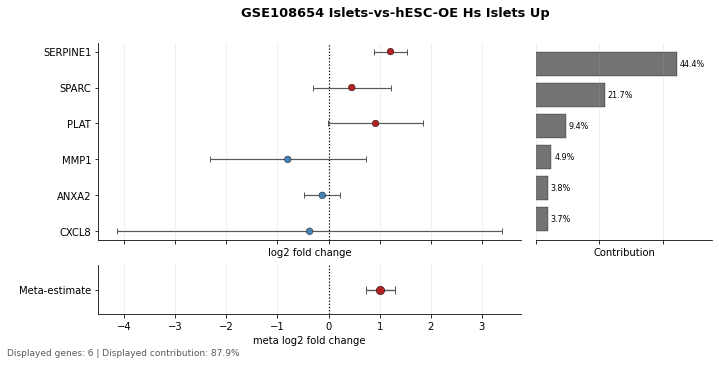

In [689]:
term = "GSE108654 Islets-vs-hESC-OE Hs Islets Up"

output = ForestPlotter(deseq_results, balanced_matrix, gene_ontology_results).plot_term(term, cutoff=0.9)